# Principal Component Analysis: From Geometry to Judgement

### This notebooks bridges class notes on PCA and neurons to PCA and Population Psychiatry Genetics
A recording from several neurons gives us several measurements for every observation. Principal component analysis (PCA) replaces those original feature columns with new coordinates chosen from the variation in the observed data. That can make a dataset easier to inspect or compress, but the representation is fitted rather than discovered as a biological truth.

This notebook starts with four observations and two features so that every calculation is visible. There are seven required **Try it** tasks. Five contain student-written code and two concentrate on prediction, diagnosis, and method choice. The datasets remain small so that the difficulty comes from making the analytical decisions and writing the important operations yourself.

## What will you be able to do by the end?

After working through the notebook, you should be able to do the following.

- Identify the observations and feature columns in a PCA analysis.
- Mean-centre a matrix, calculate covariance, and compare projected variance along candidate directions.
- Fit PCA with scikit-learn and distinguish observation scores from feature weights.
- Explain the difference between changing coordinates and discarding components.
- Decide whether features should be kept in their measured units or standardised before PCA.
- Reconstruct observations from retained components and measure loss in the original units.
- Bootstrap complete independent units, refit the representation, and interpret sign-invariant stability.
- Explain why a linear projection can fail on curved data and why t-SNE supports only cautious local-neighbour interpretation.
- Choose a method from the scientific aim and state a limit on the resulting claim.

## What route will we take?

| Part | Question | Student responsibility |
|---:|---|---|
| 1 | What problem is PCA trying to solve? | Identify the objects and predict a direction before calculation |
| 2 | How do centring and projection work? | Calculate means, covariance, scores, and projected variance |
| 3 | What does PCA software return? | Fit and transform the small dataset independently |
| 4 | How does scaling change the question? | Compare raw and standardised PCA on a small neural population |
| 5 | What is lost when components are removed? | Write a reusable reconstruction function and choose a retained dimension |
| 6 | Is the fitted direction stable? | Resample complete reaches, refit PCA, and summarise agreement |
| 7 | When should we use another method? | Diagnose a nonlinear example and choose methods from scientific aims |

## PCA at a very basic level

> **PCA is a rotation of the coordinate system.** It replaces the original feature axes with new axes chosen so that PC1 follows the largest spread in the observed data, PC2 follows the largest remaining spread at right angles to PC1, and so on.

Imagine a long, tilted cloud of points on paper. The ordinary horizontal and vertical axes may describe the cloud inefficiently. PCA rotates the ruler until its first axis lies along the cloud's longest direction. Every point then receives a new coordinate on that ruler. That coordinate is its **PC1 score**.

The basic sequence is:

1. Put observations in rows and measured features in columns.
2. Subtract each column mean so that the cloud is centred at zero.
3. Find the direction with the greatest spread of projected observations; call it PC1.
4. Find a perpendicular direction with the greatest remaining spread; call it PC2. Continue if needed.
5. Give every observation a score on each component.
6. Keep all components for a rotation with no information loss, or discard later components for dimensionality reduction.

PCA is **unsupervised**: it sees the feature matrix but is not told which participants are cases or controls. It finds large variation, not variation that is necessarily relevant to a psychiatric phenotype. If cases and controls separate on a PC, investigate ancestry, recruitment site, genotyping batch, data quality, and ascertainment before proposing a disorder-related explanation.

### A small glossary to return to

| Term | Very basic meaning | Population-genetics meaning |
|---|---|---|
| Observation | One row or one point | Usually one participant or sample |
| Feature | One measured column | Usually one SNP/variant dosage |
| Dimension | One number needed to locate an observation | One SNP axis before PCA; one PC axis after PCA |
| Variance | How spread out one column or set of scores is | How much participants differ on a variant or PC |
| Covariance | Whether two features tend to rise and fall together | Whether allele dosages at two variants co-vary across participants |
| Principal component | A new direction made as a weighted combination of all input features | A genome-wide direction made from variant weights |
| Loading/weight | How strongly one original feature contributes to a component | The weight of one variant in a genetic PC |
| Score | An observation's coordinate on a component | A participant's coordinate on a genetic PC |
| Eigenvector | The mathematical name for a component direction | The direction used to calculate genetic PC scores |
| Eigenvalue | The variance captured along that direction | The amount of genotype variation captured by that PC |
| Explained-variance ratio | A component's captured variance divided by total variance | The fraction of fitted genotype variation represented by that PC |

### The direct bridge to population psychiatric genetics

A common genetics matrix is called $G$:

- **Rows are people.**
- **Columns are variants**, often SNPs selected after quality control.
- **Entries are allele counts or dosages**, commonly 0, 1, or 2 copies of a chosen allele; imputed dosages can be continuous between 0 and 2.

#### Genetics mini-glossary

| Genetics term | Very basic meaning |
|---|---|
| Variant | A genomic position at which the DNA sequence differs among people |
| SNP | A single-nucleotide polymorphism: a variant involving one DNA letter |
| Allele | One version of the DNA sequence at a variant |
| Genotype | The pair of alleles carried by a diploid person at a variant |
| Dosage | The counted or estimated number of copies of a specified allele, usually from 0 to 2 |
| Allele frequency | The proportion of sampled chromosome copies carrying an allele |
| Imputation | Statistical estimation of unmeasured genotypes using observed markers and a reference panel |
| Linkage disequilibrium (LD) | Correlation between variants; nearby alleles can be inherited together rather than acting like independent columns |
| Population structure | Systematic genome-wide allele-frequency patterns among sampled people, often shaped by demographic history and sampling |
| Genetic ancestry | A statistical description of genetic similarity and descent relative to particular people or reference samples; it is not a fixed race label |
| Kinship/relatedness | Extra genetic similarity because people share recent family ancestry |
| GWAS | A genome-wide association study: many variants are tested for association with a phenotype |
| Covariate | An additional variable included in a statistical model to represent a measured source of variation, such as a PC or technical batch |
| Batch effect | A systematic difference caused by data collection or processing rather than the biology of interest |
| Reference panel | A set of samples used to estimate allele patterns, impute genotypes, label comparisons, or define a coordinate space |

If $G$ contains 100,000 people and 500,000 variants, the geometry is conceptually the same as the four-point example in this notebook. We simply cannot draw the original 500,000-dimensional cloud. Efficient genetics software therefore uses matrix decompositions, genetic-relationship matrices, or approximate/truncated algorithms without changing the central idea.

In population psychiatric genetics, genetic PCA is commonly used to:

- visualise broad and fine-scale population structure;
- identify ancestry-related structure, unusually placed samples, close-family structure, or possible technical batches that require investigation;
- supply selected PC scores as covariates in a GWAS so ancestry-related allele-frequency differences are less likely to be mistaken for disorder associations; and
- define a reference space and project new cohorts into comparable coordinates.

> **Critical interpretation rule:** a genetic PC is a fitted statistical axis. It is not automatically a discrete ancestry label, a race category, a psychiatric-disease axis, or a causal biological pathway. A visible cluster can reflect demographic history, family structure, sampling, genotyping platform, study site, missingness, or a mixture of these. Metadata and sensitivity checks are needed before attaching a meaning to it.

The tiny neural examples below teach the mechanics clearly. At every Try It, a **population-genetics translation** explains what the same step means when the rows are people and the columns are variants.

In [1]:
#@title 🔧 Setup, imports, and plotting helpers
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

from IPython.display import display
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

pd.set_option("display.precision", 3)

C_NEURO = "#0E8C76"
C_SECONDARY = "#6A4FB0"
C_LOSS = "#C0392B"
C_NEUTRAL = "#667085"
C_PAPER = "#FBF7F1"


def orient_component_rows(component_rows):
    """Give component rows a stable display sign without changing their axes."""
    oriented = np.asarray(component_rows, dtype=float).copy()
    largest_indices = np.argmax(np.abs(oriented), axis=1)
    signs = np.sign(oriented[np.arange(oriented.shape[0]), largest_indices])
    signs[signs == 0.0] = 1.0
    return oriented * signs[:, None], signs


def soft_check(condition, success, prompt):
    """Report task progress without breaking the runnable blank handout."""
    if condition:
        print(f"PASS: {success}")
    else:
        print(f"TO DO: {prompt}")


def finish_axes(axis):
    """Apply the quiet paper-and-emerald plot treatment used in this course."""
    axis.set_facecolor(C_PAPER)
    axis.spines[["top", "right"]].set_visible(False)
    axis.grid(alpha=0.16, linewidth=0.7)


plt.rcParams.update(
    {
        "figure.facecolor": C_PAPER,
        "axes.facecolor": C_PAPER,
        "axes.edgecolor": "#18332B",
        "text.color": "#18332B",
        "axes.labelcolor": "#18332B",
        "xtick.color": "#18332B",
        "ytick.color": "#18332B",
        "font.size": 11,
    }
)

## 1. What problem is PCA trying to solve?

We begin with four snapshots from two neurons. Each row is one observation and each column is one measured feature.

| Snapshot | Neuron A (Hz) | Neuron B (Hz) |
|---:|---:|---:|
| 1 | 1 | 1 |
| 2 | 2 | 2 |
| 3 | 3 | 2 |
| 4 | 4 | 3 |

PCA does not begin by deleting one of the neurons. It finds new coordinate directions that combine the two feature columns. Before calculating anything, inspect the cloud and predict which direction should show the greatest spread of projected observations.

### Definitions in plain language

- A **data matrix** is simply a rectangular table of numbers. Here it is called `small_cloud`.
- An **observation** is the thing being described by a row. Here it is one neural snapshot. In a genotype PCA it is usually one person.
- A **feature** is one measured property in a column. Here it is one neuron's firing rate. In a genotype PCA it is usually one variant dosage.
- A **point cloud** is all observations imagined as points. With two features we can draw it; with hundreds of thousands of SNPs we cannot, but the matrix still defines the cloud.
- A **direction** is a candidate axis through the cloud. PCA is asking: *if I could keep only one new ruler, which direction would best preserve how spread out the observations are?*

Notice that the word *population* can be used in two different ways. A neural population is a collection of recorded neurons. A human population-genetics dataset is a collection of people and their variants. PCA only sees rows and columns; the scientific meaning comes from how you define them.

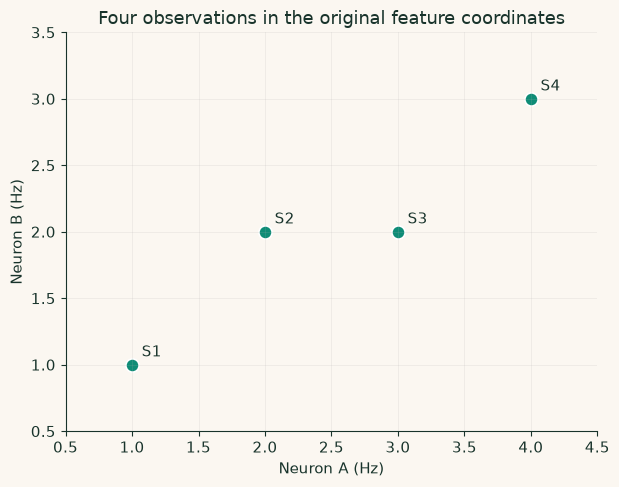

In [2]:
#@title 🔧 Create and plot the four-observation cloud
small_cloud = np.array(
    [
        [1.0, 1.0],
        [2.0, 2.0],
        [3.0, 2.0],
        [4.0, 3.0],
    ]
)
small_cloud_fixed = small_cloud.copy()
small_labels = np.array(["S1", "S2", "S3", "S4"])

fig, axis = plt.subplots(figsize=(6.7, 5.0))
axis.scatter(
    small_cloud[:, 0],
    small_cloud[:, 1],
    s=90,
    color=C_NEURO,
    edgecolor="white",
    linewidth=1.2,
)
for label, (x_value, y_value) in zip(small_labels, small_cloud):
    axis.annotate(label, (x_value, y_value), xytext=(7, 6), textcoords="offset points")
axis.set(
    xlabel="Neuron A (Hz)",
    ylabel="Neuron B (Hz)",
    title="Four observations in the original feature coordinates",
    xlim=(0.5, 4.5),
    ylim=(0.5, 3.5),
)
axis.set_aspect("equal", adjustable="box")
finish_axes(axis)
plt.tight_layout()
plt.show()

### Try it 1. What direction do you predict before fitting PCA?

Answer all three questions before running the next calculation.

1. What does one row represent, and what does one column represent?
2. Would a horizontal, vertical, or rising diagonal direction retain the greatest spread? Explain what you noticed in the observations.
3. Why is projecting onto a fitted diagonal direction different from simply deleting Neuron B?

#### Read this before answering

Do not calculate yet. First name the object represented by a row and the measurement represented by a column. Then trace the observations from S1 to S4 with your finger. A rising diagonal is plausible when both coordinates tend to increase together.

The key contrast in question 3 is:

- **Feature deletion:** keep Neuron A exactly as it was and throw away Neuron B.
- **Projection:** build a new coordinate such as `0.8 × Neuron A + 0.6 × Neuron B`. Both features can contribute to the new number. PCA learns the weights from the observed variation.

**Population-genetics translation:** one row would be one participant and one column one SNP dosage. A genetic PC score is not one chosen SNP. It is a weighted sum across many retained variants, producing one coordinate for each participant. Before fitting, you would expect participants with broadly similar genome-wide allele patterns to receive nearby scores, but you should not yet name that pattern as ancestry, batch, or disease status without checking metadata.

**Your answer**

1. One row represents **one snapshot (observation)**, and one column represents **one measured feature: a neuron's firing rate in hertz**.
2. I predict a **rising diagonal** direction because both firing rates generally increase together across the four snapshots, so the cloud is most spread out from lower left to upper right.
3. Projection onto a fitted diagonal combines information from **both** neurons into each score. Deleting Neuron B would retain only Neuron A's coordinate and ignore variation contributed by Neuron B.

## 2. How do centring and projection work?

Mean-centring subtracts each feature's column mean. It moves the centre of the cloud to the origin without changing the distances among observations. The sample covariance matrix then describes how the centred feature columns vary alone and together.

For a centred matrix $X_c$ with $n$ observations,

$$\mathrm{Cov}(X)=\frac{X_c^\mathsf{T}X_c}{n-1}. $$

A unit direction $w$ turns every centred row into one score: $z=X_cw$. PCA searches for the direction whose scores have the greatest sample variance. In this small task, you will compare two candidate directions before software performs the search.

### Definitions in plain language

- The **mean** is a column's average. Each feature has its own mean.
- **Centring** means subtracting that column mean from every entry in the column. After centring, zero means *average for this feature*. Positive means above the feature mean and negative means below it.
- **Variance** is a numerical description of spread. Large variance means the values are widely separated; small variance means they are close together.
- **Covariance** asks whether two centred columns move together. Positive covariance means above-average values in one tend to accompany above-average values in the other. Negative covariance means one tends to be above average when the other is below. Near-zero covariance means there is little linear co-movement.
- A **unit vector** is a direction with length one. Fixing its length is important: otherwise we could create an artificially huge variance just by multiplying the direction by a large number.
- A **projection** is the point's shadow on a chosen direction. The dot product calculates where that shadow lies.
- A **score** is the one-dimensional coordinate of an observation after projection.
- The **residual** is what is left perpendicular to the retained direction. It is the part that cannot be reconstructed when only that direction is kept.

Centring changes the origin, not the relative arrangement of the observations. If two people were close before centring, they remain equally close afterward. In genotype data, subtracting the expected allele count centres a variant so that zero represents the cohort or reference allele-frequency expectation rather than zero copies.

### Try it 2. Can you centre the cloud and compare two projections?

Complete the code without using `PCA` yet.

1. Calculate the two column means and subtract them from every row.
2. Calculate the $2\times2$ sample covariance matrix. `np.cov(..., rowvar=False)` is allowed, but also check that you understand why rows are observations.
3. Project the centred rows onto the supplied horizontal and diagonal unit directions.
4. Calculate the sample variance of each set of scores using `ddof=1`.
5. For each direction, calculate the captured sum of squares, the orthogonal residual sum of squares, and their common total.

#### Read the code task one operation at a time

1. `small_cloud.mean(axis=0)` means: travel down the rows and return one mean for each column. Its shape is `(2,)`.
2. Subtracting that two-number vector from the `(4, 2)` matrix uses NumPy **broadcasting**: the appropriate column mean is subtracted from every row.
3. `np.cov(..., rowvar=False)` says that rows are observations and columns are the variables whose covariance we want. The diagonal entries are the two feature variances; the off-diagonal entry is their covariance.
4. `centred_matrix @ directions.T` calculates every observation's score on every candidate direction. The result has four rows and two score columns.
5. `ddof=1` requests sample variance with denominator `n - 1`.
6. Squared scores measure variation captured along the direction. Squared perpendicular residuals measure variation lost. For the same centred data, **captured + lost = one fixed total**. A better one-dimensional direction captures more and loses less.

**Population-genetics translation:** with people in rows and SNPs in columns, centring removes each SNP's mean dosage. Two SNP columns can covary because of linkage disequilibrium, population structure, or both. In a very large genotype matrix, you usually do not explicitly create an enormous variant-by-variant covariance matrix in NumPy. Tools such as PLINK use efficient relationship-matrix or approximate decomposition methods, but the conceptual target is still the direction with large projected variance.

In [3]:
student_small_mean = small_cloud.mean(axis=0)
student_small_centred = small_cloud - student_small_mean
student_small_covariance = np.cov(student_small_centred, rowvar=False)

candidate_directions = np.array(
    [
        [1.0, 0.0],
        [1.0, 1.0],
    ]
)
candidate_directions[1] = candidate_directions[1] / np.linalg.norm(
    candidate_directions[1]
)

student_candidate_scores = student_small_centred @ candidate_directions.T
student_candidate_variances = student_candidate_scores.var(axis=0, ddof=1)
student_candidate_captured_ss = np.sum(student_candidate_scores**2, axis=0)
student_candidate_lost_ss = np.array(
    [
        np.sum(
            (
                student_small_centred
                - student_candidate_scores[:, [index]] * direction
            )
            ** 2
        )
        for index, direction in enumerate(candidate_directions)
    ]
)
student_total_centred_ss = np.sum(student_small_centred**2)

**Your answer**

The column means are **[2.5, 2.0]**, and the off-diagonal covariance is **1.0**.

For the horizontal direction, the score variance is **1.667**, the captured sum of squares is **5.0**, and the lost sum of squares is **2.0**.

For the 45° diagonal, the score variance is **2.167**, the captured sum of squares is **6.5**, and the lost sum of squares is **0.5**. Both decompositions have the same total centred sum of squares, **7.0**.

The **diagonal** is better because it captures more projected variance and leaves less orthogonal reconstruction loss.

In [4]:
#@title 💡 Reference calculation and Try it 2 check — open after attempting
small_mean_reference = small_cloud_fixed.mean(axis=0)
small_centred_reference = small_cloud_fixed - small_mean_reference
small_covariance_reference = np.cov(small_centred_reference, rowvar=False)
candidate_directions_reference = np.array(
    [
        [1.0, 0.0],
        [1.0 / np.sqrt(2.0), 1.0 / np.sqrt(2.0)],
    ]
)
candidate_scores_reference = (
    small_centred_reference @ candidate_directions_reference.T
)
candidate_variances_reference = candidate_scores_reference.var(axis=0, ddof=1)
candidate_captured_ss_reference = np.sum(candidate_scores_reference**2, axis=0)
candidate_lost_ss_reference = np.array(
    [
        np.sum(
            (
                small_centred_reference
                - candidate_scores_reference[:, [index]] * direction
            )
            ** 2
        )
        for index, direction in enumerate(candidate_directions_reference)
    ]
)
total_centred_ss_reference = np.sum(small_centred_reference**2)

task2_ready = all(
    value is not None
    for value in (
        student_small_mean,
        student_small_centred,
        student_small_covariance,
        student_candidate_scores,
        student_candidate_variances,
        student_candidate_captured_ss,
        student_candidate_lost_ss,
        student_total_centred_ss,
    )
)
task2_correct = False
if task2_ready:
    try:
        task2_correct = (
            np.allclose(student_small_mean, small_mean_reference)
            and np.allclose(small_cloud, small_cloud_fixed)
            and np.allclose(student_small_centred, small_centred_reference)
            and np.allclose(student_small_centred.mean(axis=0), 0.0)
            and np.allclose(student_small_covariance, small_covariance_reference)
            and np.allclose(candidate_directions, candidate_directions_reference)
            and np.allclose(student_candidate_scores, candidate_scores_reference)
            and np.allclose(student_candidate_variances, candidate_variances_reference)
            and np.allclose(
                student_candidate_captured_ss,
                candidate_captured_ss_reference,
            )
            and np.allclose(student_candidate_lost_ss, candidate_lost_ss_reference)
            and np.isclose(student_total_centred_ss, total_centred_ss_reference)
            and np.allclose(
                np.asarray(student_candidate_captured_ss)
                + np.asarray(student_candidate_lost_ss),
                student_total_centred_ss,
            )
        )
    except (TypeError, ValueError, AttributeError):
        task2_correct = False

soft_check(
    task2_correct,
    "Try it 2 centres, projects, and calculates both score variances correctly.",
    "complete every Try it 2 variable and rerun this check.",
)

PASS: Try it 2 centres, projects, and calculates both score variances correctly.


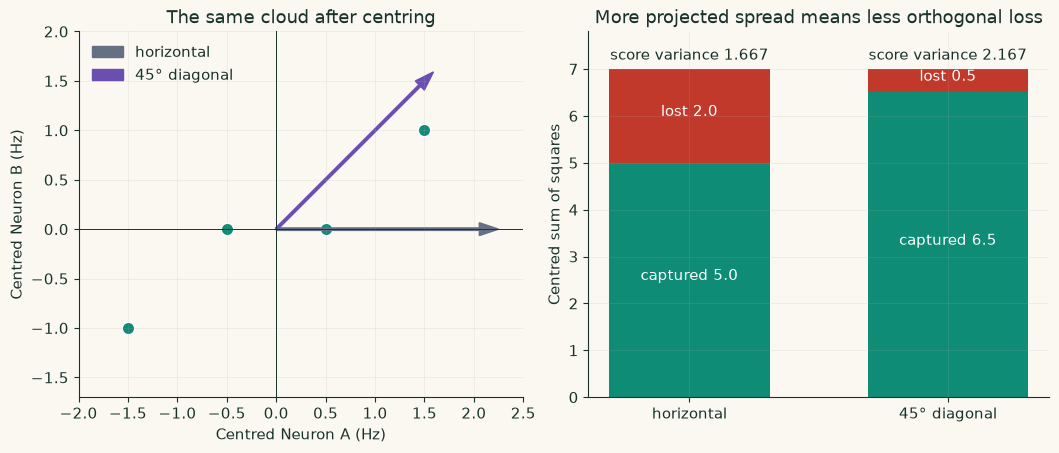

In [5]:
#@title 🔧 Plot and explore candidate projection directions
fig, (cloud_axis, variance_axis) = plt.subplots(1, 2, figsize=(10.8, 4.5))

cloud_axis.scatter(
    small_centred_reference[:, 0],
    small_centred_reference[:, 1],
    s=82,
    color=C_NEURO,
    edgecolor="white",
    linewidth=1.1,
)
arrow_length = 2.25
for direction, colour, label in zip(
    candidate_directions_reference,
    [C_NEUTRAL, C_SECONDARY],
    ["horizontal", "45° diagonal"],
):
    cloud_axis.arrow(
        0,
        0,
        arrow_length * direction[0],
        arrow_length * direction[1],
        width=0.025,
        head_width=0.13,
        length_includes_head=True,
        color=colour,
        label=label,
    )
cloud_axis.axhline(0, color="#18332B", linewidth=0.7)
cloud_axis.axvline(0, color="#18332B", linewidth=0.7)
cloud_axis.set(
    xlabel="Centred Neuron A (Hz)",
    ylabel="Centred Neuron B (Hz)",
    title="The same cloud after centring",
    xlim=(-2.0, 2.5),
    ylim=(-1.7, 2.0),
)
cloud_axis.set_aspect("equal", adjustable="box")
cloud_axis.legend(frameon=False, loc="upper left")
finish_axes(cloud_axis)

direction_names = ["horizontal", "45° diagonal"]
variance_axis.bar(
    direction_names,
    candidate_captured_ss_reference,
    color=C_NEURO,
    width=0.62,
    label="captured along direction",
)
variance_axis.bar(
    direction_names,
    candidate_lost_ss_reference,
    bottom=candidate_captured_ss_reference,
    color=C_LOSS,
    width=0.62,
    label="lost orthogonally",
)
variance_axis.set(
    ylabel="Centred sum of squares",
    title="More projected spread means less orthogonal loss",
    ylim=(0, 7.8),
)
for index, (captured, lost, variance) in enumerate(
    zip(
        candidate_captured_ss_reference,
        candidate_lost_ss_reference,
        candidate_variances_reference,
    )
):
    variance_axis.text(index, captured / 2, f"captured {captured:.1f}", ha="center", color="white")
    variance_axis.text(index, captured + lost / 2, f"lost {lost:.1f}", ha="center", color="white")
    variance_axis.text(index, 7.2, f"score variance {variance:.3f}", ha="center")
finish_axes(variance_axis)

plt.tight_layout()
plt.show()


def explore_projection_direction(angle_degrees=45):
    """Show how one candidate axis changes scores, spread, and residual loss."""
    angle_radians = np.deg2rad(angle_degrees)
    direction = np.array([np.cos(angle_radians), np.sin(angle_radians)])
    scores = small_centred_reference @ direction
    projected_points = scores[:, None] * direction
    captured_ss = float(np.sum(scores**2))
    lost_ss = float(np.sum((small_centred_reference - projected_points) ** 2))
    score_variance = float(scores.var(ddof=1))

    fig, (projection_axis, score_axis) = plt.subplots(
        1,
        2,
        figsize=(10.8, 4.2),
    )
    projection_axis.scatter(
        small_centred_reference[:, 0],
        small_centred_reference[:, 1],
        s=78,
        color=C_NEURO,
        edgecolor="white",
        linewidth=1.1,
        label="centred observation",
        zorder=3,
    )
    direction_extent = 2.7
    projection_axis.plot(
        [-direction_extent * direction[0], direction_extent * direction[0]],
        [-direction_extent * direction[1], direction_extent * direction[1]],
        color=C_SECONDARY,
        linewidth=2.0,
        label="candidate axis",
        zorder=1,
    )
    projection_axis.scatter(
        projected_points[:, 0],
        projected_points[:, 1],
        s=62,
        facecolor=C_PAPER,
        edgecolor=C_SECONDARY,
        linewidth=1.6,
        label="projection",
        zorder=4,
    )
    for observed, projected in zip(small_centred_reference, projected_points):
        projection_axis.plot(
            [observed[0], projected[0]],
            [observed[1], projected[1]],
            color=C_LOSS,
            linewidth=1.0,
            alpha=0.72,
            zorder=2,
        )
    projection_axis.axhline(0, color="#18332B", linewidth=0.7)
    projection_axis.axvline(0, color="#18332B", linewidth=0.7)
    projection_axis.set(
        xlabel="Centred Neuron A (Hz)",
        ylabel="Centred Neuron B (Hz)",
        title=f"Candidate direction = {angle_degrees:.0f}°",
        xlim=(-2.25, 2.25),
        ylim=(-2.25, 2.25),
    )
    projection_axis.set_aspect("equal", adjustable="box")
    projection_axis.legend(frameon=False, fontsize=8, loc="upper left")
    finish_axes(projection_axis)

    score_axis.scatter(
        scores,
        np.zeros(len(scores)),
        s=82,
        color=C_SECONDARY,
        edgecolor="white",
        linewidth=1.1,
    )
    for label, score in zip(small_labels, scores):
        score_axis.annotate(
            label,
            (score, 0),
            xytext=(0, 9),
            textcoords="offset points",
            ha="center",
        )
    score_axis.axhline(0, color="#18332B", linewidth=0.8)
    score_axis.set(
        xlabel="Projected score",
        yticks=[],
        title=(
            f"variance = {score_variance:.3f}\n"
            f"captured = {captured_ss:.2f}, lost = {lost_ss:.2f}"
        ),
        xlim=(-2.45, 2.45),
        ylim=(-0.35, 0.48),
    )
    finish_axes(score_axis)

    plt.tight_layout()
    plt.show()


if widgets is not None:
    projection_angle_control = widgets.FloatSlider(
        value=45,
        min=0,
        max=180,
        step=1,
        description="angle (°)",
        continuous_update=False,
        readout_format=".0f",
    )
    projection_angle_panel = widgets.interactive_output(
        explore_projection_direction,
        {"angle_degrees": projection_angle_control},
    )
    display(
        widgets.VBox(
            [
                widgets.HTML(
                    "<b>Explore:</b> rotate the same candidate axis. "
                    "Look for high score variance and low orthogonal loss."
                ),
                projection_angle_control,
                projection_angle_panel,
            ]
        )
    )
else:
    print(
        "Interactive angle control unavailable. The stored comparison above "
        "contains the core result."
    )

The off-diagonal covariance is positive: observations above the mean for Neuron A also tend to be above the mean for Neuron B. For a unit direction, the captured sum of squares is $(n-1)$ times the sample variance of its scores. The centred total is fixed and divides into captured plus orthogonal residual sums of squares. Maximising projected variance is therefore equivalent to minimising squared orthogonal reconstruction loss at the same retained dimension. The fitted first principal direction will be close to the better diagonal candidate, but PCA is not restricted to the two directions we happened to compare.

## 3. What does PCA software return?

Scikit-learn performs the search and returns several different objects.

- `components_` contains one direction per row. These are **feature weights**.
- `transform(X)` returns one row per observation. These are **observation scores**.
- `explained_variance_ratio_` reports each component's share of the total variance in this fitted dataset.
- `inverse_transform(scores)` returns from component coordinates to the original feature coordinates.

Component signs are arbitrary. A direction and its negative describe the same axis, so a correct comparison must allow both signs.

Why can a sign flip? A line pointing north-east is the same geometric axis as a line pointing south-west. Software may label either end positive. If the component weights change sign, all scores on that component also change sign, but distances and reconstruction remain the same.

**Population-genetics translation:** a sample-score file has one row per person and one PC coordinate per requested component. An allele-weight file has one weight per variant per component. Scores are what you usually plot or include as GWAS covariates. Variant weights tell you how the fitted axis was constructed, but a large weight does not by itself prove a causal or psychiatric-risk variant.

### Try it 3. Can you fit and interrogate PCA independently?

Starting only from `small_cloud`, write the complete scikit-learn analysis.

1. Create a two-component PCA object and fit it to the raw cloud.
2. Transform the observations into scores.
3. Extract the component weights and explained-variance ratios.
4. Confirm for yourself that the score matrix has one row per snapshot while the weight matrix has one column per original feature.

#### Keep the object shapes beside you

| Object | Meaning | Shape in this task | Shape for `n` people, `m` variants, and `k` PCs |
|---|---|---:|---:|
| Input matrix | observations × features | `4 × 2` | `n × m` |
| Scores | observations × retained PCs | `4 × 2` | `n × k` |
| Weights | retained PCs × original features | `2 × 2` | `k × m` |
| Explained-variance ratios | one value per retained PC | `2` | `k` |

`fit_transform(X)` is a convenient combination of two steps: learn the PCA from `X`, then score `X` in the learned space. Later, `transform(new_X)` uses the already-learned axes; it does not refit them.

**Population-genetics translation:** suppose 100,000 participants have 500,000 retained SNPs and you request 20 PCs. Conceptually, the participant-score matrix is `100000 × 20`, while the variant-weight matrix is `20 × 500000`. To compare future cohorts in the same space, keep the reference allele frequencies and weights fixed and **project** the new participants. Refitting PCA separately in every cohort creates different axes, so PC1 in cohort A need not be directly comparable with PC1 in cohort B.

In [7]:
student_small_pca = PCA(n_components=2)
student_small_scores = student_small_pca.fit_transform(small_cloud)
student_small_weights = student_small_pca.components_
student_small_evr = student_small_pca.explained_variance_ratio_

**Your answer**

The score matrix has shape **(4, 2)**, the weight matrix has shape **(2, 2)**, and PC1 explains approximately **97.9%** of the variance.

Keeping both components is a change of coordinates and reconstructs all four observations apart from rounding, while keeping only PC1 is a dimensionality reduction that discards the PC2 variation and introduces reconstruction loss.

Reversing a component's sign does not change its axis, explained variance, or reconstruction; its weights and corresponding scores simply reverse sign together.

In [8]:
#@title 💡 Reference PCA and Try it 3 check — open after attempting
small_pca_reference = PCA(n_components=2)
small_scores_reference = small_pca_reference.fit_transform(small_cloud_fixed)
small_weights_reference = small_pca_reference.components_
small_evr_reference = small_pca_reference.explained_variance_ratio_

task3_ready = all(
    value is not None
    for value in (
        student_small_pca,
        student_small_scores,
        student_small_weights,
        student_small_evr,
    )
)
task3_correct = False
if task3_ready:
    try:
        direction_agreement = np.abs(
            np.asarray(student_small_weights) @ small_weights_reference.T
        )
        task3_correct = (
            isinstance(student_small_pca, PCA)
            and np.allclose(small_cloud, small_cloud_fixed)
            and np.allclose(student_small_pca.mean_, small_mean_reference)
            and np.asarray(student_small_scores).shape == (4, 2)
            and np.asarray(student_small_weights).shape == (2, 2)
            and np.asarray(student_small_evr).shape == (2,)
            and np.allclose(direction_agreement, np.eye(2), atol=1e-8)
            and np.allclose(
                student_small_scores,
                (small_cloud_fixed - student_small_pca.mean_)
                @ np.asarray(student_small_weights).T,
            )
            and np.allclose(student_small_evr, small_evr_reference)
        )
    except (TypeError, ValueError, AttributeError):
        task3_correct = False

soft_check(
    task3_correct,
    "Try it 3 fits the intended cloud and separates scores, weights, and variance.",
    "fit PCA to small_cloud and extract all four requested outputs.",
)

PASS: Try it 3 fits the intended cloud and separates scores, weights, and variance.


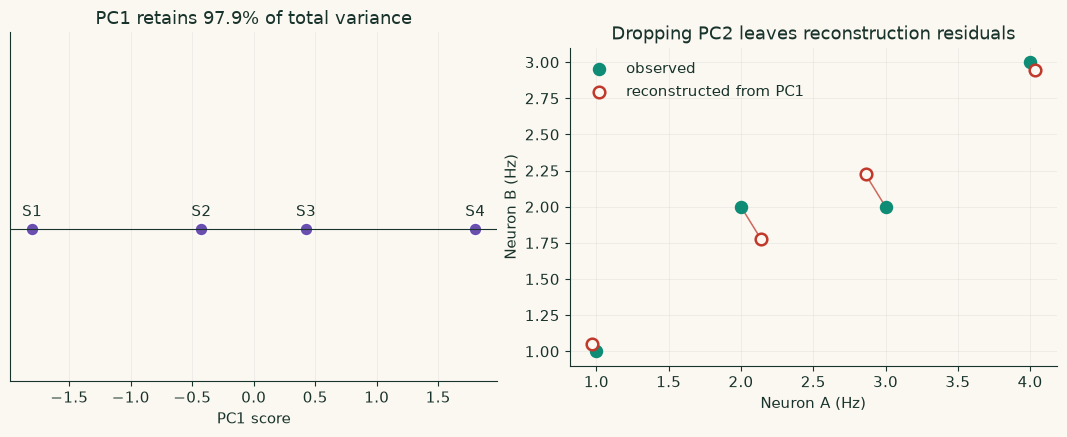

In [9]:
#@title 🔧 Plot PCA scores and one-component reconstruction
small_oriented_weights, small_orientation_signs = orient_component_rows(
    small_weights_reference
)
small_oriented_scores = small_scores_reference * small_orientation_signs
small_pc1_reconstruction = (
    small_oriented_scores[:, :1] @ small_oriented_weights[:1]
    + small_pca_reference.mean_
)

fig, (score_axis, reconstruction_axis) = plt.subplots(1, 2, figsize=(10.8, 4.5))

score_axis.scatter(
    small_oriented_scores[:, 0],
    np.zeros(len(small_cloud)),
    s=85,
    color=C_SECONDARY,
    edgecolor="white",
)
for label, score in zip(small_labels, small_oriented_scores[:, 0]):
    score_axis.annotate(label, (score, 0), xytext=(0, 9), textcoords="offset points", ha="center")
score_axis.axhline(0, color="#18332B", linewidth=0.8)
score_axis.set(
    xlabel="PC1 score",
    yticks=[],
    title=f"PC1 retains {small_evr_reference[0]:.1%} of total variance",
    ylim=(-0.35, 0.45),
)
finish_axes(score_axis)

reconstruction_axis.scatter(
    small_cloud_fixed[:, 0],
    small_cloud_fixed[:, 1],
    s=75,
    color=C_NEURO,
    label="observed",
    zorder=3,
)
reconstruction_axis.scatter(
    small_pc1_reconstruction[:, 0],
    small_pc1_reconstruction[:, 1],
    s=70,
    facecolor=C_PAPER,
    edgecolor=C_LOSS,
    linewidth=1.8,
    label="reconstructed from PC1",
    zorder=4,
)
for observed, reconstructed in zip(small_cloud_fixed, small_pc1_reconstruction):
    reconstruction_axis.plot(
        [observed[0], reconstructed[0]],
        [observed[1], reconstructed[1]],
        color=C_LOSS,
        linewidth=1.1,
        alpha=0.75,
    )
reconstruction_axis.set(
    xlabel="Neuron A (Hz)",
    ylabel="Neuron B (Hz)",
    title="Dropping PC2 leaves reconstruction residuals",
)
reconstruction_axis.set_aspect("equal", adjustable="box")
reconstruction_axis.legend(frameon=False)
finish_axes(reconstruction_axis)

plt.tight_layout()
plt.show()

Keeping both components only rotates the coordinate system and reconstructs all four observations apart from numerical rounding. Keeping PC1 alone is a reduction: the discarded PC2 scores become the residual distances shown in red.

## 4. How does scaling change the scientific question?

We now move to a small simulated neural population recorded during 12 complete reaches. One row is one reach-by-time-bin observation. Each reach contributes four time bins, giving 48 rows, and the six columns are the same six simultaneously recorded neurons throughout. Rows from the same reach are dependent and belong together, which will matter when we bootstrap later.

The simulation is intentionally small. It represents two shared population patterns, reach-to-reach shifts, and measurement noise. It is a teaching dataset rather than evidence about a real neural mechanism.

### Definitions in plain language

- **Scale** means the numerical size and units of a feature. A firing-rate column varying by 10 Hz has a larger raw scale than one varying by 1 Hz.
- **Standardisation** usually means subtract the column mean and divide by the column standard deviation. The result has mean zero and variance near one.
- **Raw PCA** allows high-variance columns to influence the leading components more strongly. This can be scientifically correct when absolute units and absolute variation are meaningful.
- **Standardised PCA** gives each input column comparable initial variance. This can be scientifically correct when relative patterns matter more than original-unit spread.

Scaling is not cosmetic. It defines what *large variation* means, so it can rotate the components and change every score.

### How genotype PCA is usually standardised

For a diploid biallelic variant $j$, let $G_{ij}$ be participant $i$'s allele dosage and let $p_j$ be the chosen allele frequency. A common genetics transformation is approximately

$$Z_{ij}=\frac{G_{ij}-2p_j}{\sqrt{2p_j(1-p_j)}}. $$

The numerator centres the dosage around its expected count. The denominator scales by the expected genotype spread under the usual diploid model. This resembles `StandardScaler`, but production genetics tools also handle allele coding, frequency estimation, missing calls, multiallelic variants, and file formats explicitly.

Do not interpret PCA from an unfiltered genotype matrix as if it were automatically population structure. A practical ancestry-PCA input commonly requires:

- consistent genome build, strand, reference/alternate allele coding, and variant identifiers across datasets;
- sample and variant quality control for missingness and genotype quality;
- a defensible minor-allele-frequency range, because variance standardisation can behave poorly for extremely rare variants;
- autosomal, approximately independent variants for a conventional global structure analysis;
- linkage-disequilibrium pruning and often exclusion or special handling of long-range-LD regions, so one correlated genomic region does not dominate a global PC; and
- explicit handling of duplicates and close relatives, often by fitting axes in a relatively unrelated set and projecting excluded relatives afterward.

After fitting, compare PC plots with ancestry reference samples and with technical metadata such as study, recruitment site, genotyping array, sequencing centre, processing batch, missingness, and case/control status. A component aligned with one batch is evidence to investigate the batch, not permission to rename the component as ancestry.

Neural matrix shape = (48, 6)


,reach,reach_index,time_bin,time
0,R01,0,0,0.00
1,R01,0,1,0.33
2,R01,0,2,0.67
3,R01,0,3,1.00
4,R02,1,0,0.00
5,R02,1,1,0.33
6,R02,1,2,0.67
7,R02,1,3,1.00


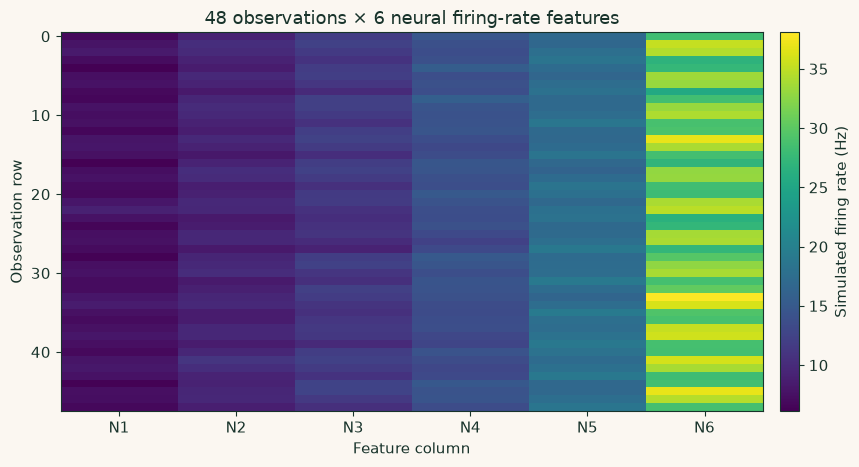

In [10]:
#@title 🔧 Simulate and plot the six-neuron population
neural_rng = np.random.default_rng(206)
reach_names = np.array([f"R{index:02d}" for index in range(1, 13)])
time_values = np.array([0.0, 0.33, 0.67, 1.0])
neuron_names = np.array([f"N{index}" for index in range(1, 7)])

reach_offsets = neural_rng.normal(
    0.0,
    [0.30, 0.35, 0.30, 0.45, 0.40, 1.20],
    size=(len(reach_names), len(neuron_names)),
)
pattern_a = np.array([0.9, 1.1, 0.7, -0.5, -0.8, 7.5])
pattern_b = np.array([-0.5, 0.3, 1.2, 0.9, -1.0, 0.6])
baseline_rates = np.array([7.0, 9.0, 11.0, 14.0, 18.0, 28.0])

activity_rows = []
metadata_rows = []
for reach_index, reach_name in enumerate(reach_names):
    reach_gain = 1.0 + neural_rng.normal(0.0, 0.08)
    for time_index, time_value in enumerate(time_values):
        movement = reach_gain * np.sin(np.pi * time_value)
        shared_time = np.cos(np.pi * time_value)
        measurement_noise = neural_rng.normal(
            0.0,
            [0.18, 0.22, 0.20, 0.28, 0.25, 0.75],
        )
        row = (
            baseline_rates
            + reach_offsets[reach_index]
            + movement * pattern_a
            + 0.65 * shared_time * pattern_b
            + measurement_noise
        )
        activity_rows.append(row)
        metadata_rows.append(
            {
                "reach": reach_name,
                "reach_index": reach_index,
                "time_bin": time_index,
                "time": time_value,
            }
        )

neural_activity = np.asarray(activity_rows)
neural_metadata = pd.DataFrame(metadata_rows)
neural_reach_index = neural_metadata["reach_index"].to_numpy()
neural_time_index = neural_metadata["time_bin"].to_numpy()
neural_activity_fixed = neural_activity.copy()
neural_reach_index_fixed = neural_reach_index.copy()

print(f"Neural matrix shape = {neural_activity.shape}")
display(neural_metadata.head(8))

fig, axis = plt.subplots(figsize=(9.3, 4.8))
image = axis.imshow(neural_activity, aspect="auto", cmap="viridis")
axis.set(
    xlabel="Feature column",
    ylabel="Observation row",
    xticks=np.arange(len(neuron_names)),
    xticklabels=neuron_names,
    title="48 observations × 6 neural firing-rate features",
)
colourbar = fig.colorbar(image, ax=axis, pad=0.02)
colourbar.set_label("Simulated firing rate (Hz)")
plt.tight_layout()
plt.show()

Standardising changes every feature to a mean of zero and standard deviation of one before PCA. That prevents a neuron with a larger numerical spread from dominating only because of its scale. It also changes the scientific question.

- Raw PCA asks which directions contain the greatest **absolute firing-rate variation in hertz**.
- Standardised PCA asks which directions contain the greatest **relative variation after each neuron receives equal variance**.

Neither choice is automatically correct. The choice should follow the measurement units and the purpose of the analysis.

### Try it 4. Can you fit raw and standardised PCA and defend the difference?

Write both two-component analyses yourself.

1. Fit raw PCA directly to `neural_activity` and calculate the raw scores.
2. Fit a `StandardScaler` to the six columns and transform the matrix.
3. Fit a second PCA to the standardised matrix and calculate its scores.
4. Compare the first-component weights and explained-variance ratios.
5. In the response space, choose a scaling convention for a scientist interested in relative co-fluctuation across neurons. Also state what must be fitted only on training reaches if this PCA becomes part of a predictive pipeline.

#### What you are comparing

Fit two analyses to the same rows:

- In the **raw analysis**, PCA sees hertz directly. A neuron with much larger absolute variability may dominate PC1.
- In the **standardised analysis**, every neuron begins with variance one. PC1 then follows a relative pattern of co-fluctuation.

Compare **absolute** component weights because a component's sign can flip. Also compare the explained-variance ratios: after standardisation, the total variance has been redistributed across equal-variance starting columns.

The predictive-pipeline sentence is testing data leakage. A scaler learns means and standard deviations, and PCA learns directions. For a model evaluated on new participants or new sites, both must be learned from training data only, or fixed from an external reference, and then applied unchanged to held-out data.

**Population psychiatric genetics translation:** do not replace a genotype-aware PCA workflow with `StandardScaler` on a huge dosage CSV. Use an established genetics tool and a documented QC/LD/reference procedure. For supervised psychiatric prediction, allele-frequency estimates, imputation choices that use sample statistics, variant selection, PCA, and the downstream model must respect the training/test design. For a descriptive cohort PCA or GWAS covariate analysis, the exact fitting set can follow a different, pre-specified design; state it clearly and check whether PCs track study or case/control ascertainment. PCs can reduce ordinary stratification, but they cannot rescue a design in which diagnosis and technical batch are nearly inseparable.

In [11]:
student_neural_raw_pca = PCA(n_components=2)
student_neural_raw_scores = student_neural_raw_pca.fit_transform(
    neural_activity
)

student_neural_scaler = StandardScaler()
student_neural_scaled = student_neural_scaler.fit_transform(neural_activity)
student_neural_scaled_pca = PCA(n_components=2)
student_neural_scaled_scores = student_neural_scaled_pca.fit_transform(
    student_neural_scaled
)

**Your answer**

Raw PC1 explains approximately **87.8%** of the variance, and **N6** has the dominant absolute PC1 weight (approximately **0.972**).

Standardised PC1 explains approximately **48.5%** of the variance, and the first two standardised components cumulatively explain approximately **85.0%**.

I would use **standardised PCA** for relative co-fluctuation because it gives each neuron equal variance before finding the shared directions, rather than letting the largest absolute firing-rate variation dominate.

In a predictive pipeline, I would fit **both the scaler and PCA** using the training reaches only within each split, then use those fitted transformations on the held-out reaches.

In [12]:
#@title 💡 Reference scaling analyses and Try it 4 check — open after attempting
neural_raw_pca_reference = PCA(n_components=2)
neural_raw_scores_reference = neural_raw_pca_reference.fit_transform(
    neural_activity_fixed
)

neural_scaler_reference = StandardScaler()
neural_scaled_reference = neural_scaler_reference.fit_transform(
    neural_activity_fixed
)
neural_scaled_pca_reference = PCA(n_components=2)
neural_scaled_scores_reference = neural_scaled_pca_reference.fit_transform(
    neural_scaled_reference
)

task4_ready = all(
    value is not None
    for value in (
        student_neural_raw_pca,
        student_neural_raw_scores,
        student_neural_scaler,
        student_neural_scaled,
        student_neural_scaled_pca,
        student_neural_scaled_scores,
    )
)
task4_correct = False
if task4_ready:
    try:
        raw_agreement = np.abs(
            np.asarray(student_neural_raw_pca.components_)
            @ neural_raw_pca_reference.components_.T
        )
        scaled_agreement = np.abs(
            np.asarray(student_neural_scaled_pca.components_)
            @ neural_scaled_pca_reference.components_.T
        )
        task4_correct = (
            isinstance(student_neural_raw_pca, PCA)
            and isinstance(student_neural_scaler, StandardScaler)
            and isinstance(student_neural_scaled_pca, PCA)
            and np.allclose(neural_activity, neural_activity_fixed)
            and np.allclose(
                student_neural_raw_pca.mean_,
                neural_activity_fixed.mean(axis=0),
            )
            and np.allclose(
                student_neural_scaler.mean_,
                neural_activity_fixed.mean(axis=0),
            )
            and np.allclose(student_neural_scaled, neural_scaled_reference)
            and np.allclose(student_neural_scaled.mean(axis=0), 0.0, atol=1e-12)
            and np.allclose(raw_agreement, np.eye(2), atol=1e-8)
            and np.allclose(scaled_agreement, np.eye(2), atol=1e-8)
            and np.allclose(
                student_neural_raw_scores,
                student_neural_raw_pca.transform(neural_activity_fixed),
            )
            and np.allclose(
                student_neural_scaled_scores,
                student_neural_scaled_pca.transform(student_neural_scaled),
            )
        )
    except (TypeError, ValueError, AttributeError):
        task4_correct = False

soft_check(
    task4_correct,
    "Try it 4 fits both PCA representations to the intended matrices.",
    "fit the raw and standardised analyses and rerun this check.",
)

PASS: Try it 4 fits both PCA representations to the intended matrices.


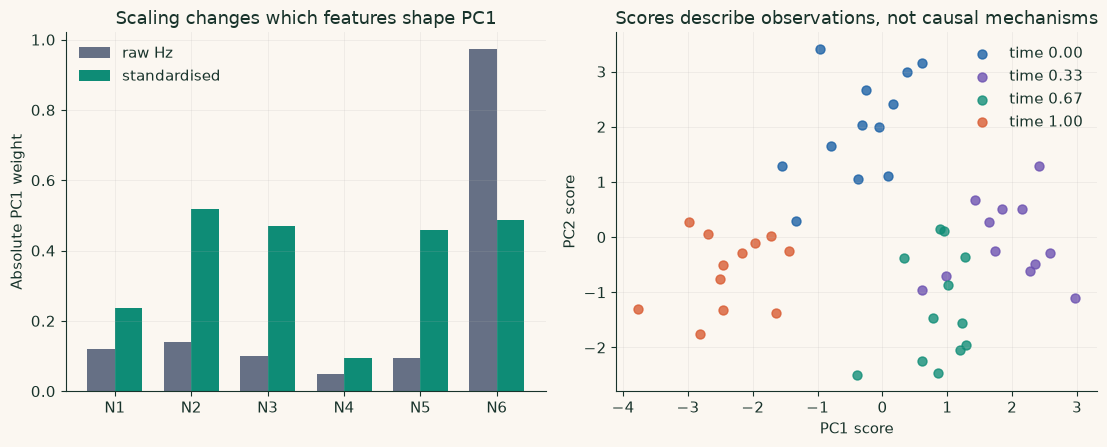

In [13]:
#@title 🔧 Plot the effect of scaling on weights and scores
raw_weights_display, _ = orient_component_rows(
    neural_raw_pca_reference.components_
)
scaled_weights_display, _ = orient_component_rows(
    neural_scaled_pca_reference.components_
)

fig, (weight_axis, score_axis) = plt.subplots(1, 2, figsize=(11.2, 4.6))
positions = np.arange(len(neuron_names))
bar_width = 0.36
weight_axis.bar(
    positions - bar_width / 2,
    np.abs(raw_weights_display[0]),
    width=bar_width,
    color=C_NEUTRAL,
    label="raw Hz",
)
weight_axis.bar(
    positions + bar_width / 2,
    np.abs(scaled_weights_display[0]),
    width=bar_width,
    color=C_NEURO,
    label="standardised",
)
weight_axis.set(
    xticks=positions,
    xticklabels=neuron_names,
    ylabel="Absolute PC1 weight",
    title="Scaling changes which features shape PC1",
)
weight_axis.legend(frameon=False)
finish_axes(weight_axis)

time_colours = ["#185FA5", C_SECONDARY, C_NEURO, "#D85A30"]
for time_index, (time_value, colour) in enumerate(zip(time_values, time_colours)):
    rows = neural_time_index == time_index
    score_axis.scatter(
        neural_scaled_scores_reference[rows, 0],
        neural_scaled_scores_reference[rows, 1],
        s=42,
        alpha=0.78,
        color=colour,
        label=f"time {time_value:.2f}",
    )
score_axis.set(
    xlabel="PC1 score",
    ylabel="PC2 score",
    title="Scores describe observations, not causal mechanisms",
)
score_axis.legend(frameon=False)
finish_axes(score_axis)

plt.tight_layout()
plt.show()

The time colours can help us inspect the representation, but visible progression does not prove that PCA discovered a movement mechanism. PCA was fitted without using the time labels and only followed variance in this simulated dataset.

## 5. What is lost when components are removed?

`transform` maps observations into component coordinates. `inverse_transform` maps retained scores back into feature coordinates. If standardisation was used, the final reconstruction must also be returned to the original firing-rate units before its loss is reported.

The reconstruction mean-squared error is

$$\mathrm{MSE}=\frac{1}{np}\sum_{i=1}^{n}\sum_{j=1}^{p}(x_{ij}-\hat{x}_{ij})^2.$$

Explained variance and reconstruction loss describe this fitted representation. Neither quantity is predictive accuracy or biological importance.

### Definitions in plain language

- A **coordinate change** keeps all components. It is like describing the same location using a rotated map; nothing important has been discarded.
- **Dimensionality reduction** happens only when fewer components are kept than original features.
- **Reconstruction** asks what the original feature values would look like if only the retained scores and weights were available.
- **Reconstruction error** is the difference between the observed value and that approximation.
- **Mean-squared error (MSE)** squares all reconstruction errors and averages them. Squaring makes positive and negative errors contribute rather than cancel. If the original unit is Hz, MSE has units Hz².
- **Cumulative explained variance** adds the explained-variance ratios from PC1 through PC$k$. A 90% rule means choosing the first $k$ for which this running total reaches at least 0.90.

A 90% threshold is a transparent teaching rule, not a universal law. It says *retain enough axes to reproduce much of this dataset's overall spread*. It does not say those axes contain 90% of the information needed for a diagnosis, exposure, treatment response, or scientific mechanism. A low-variance direction can still be relevant to a supervised outcome, and a high-variance direction can be nuisance variation.

**Population-genetics caution:** ancestry PCs often explain only a small fraction of the total variation across hundreds of thousands of SNPs while still being important confounding covariates. Genetic studies therefore do not usually choose GWAS covariate PCs by demanding 90% of all genotype variance. There is no universal correct number. Investigators use population structure, study design, eigenvalue patterns, association diagnostics, external reference information, and sensitivity analyses. Too few PCs can leave confounding; unnecessary PCs can cost precision or remove variation that the scientific model intended to study.

### Try it 5. Can you reconstruct in the original units and choose a retained dimension?

Complete `student_reconstruct_pca`. It must standardise `X`, fit a `PCA(n_components=k)`, reconstruct with `inverse_transform`, reverse the scaling, and return the reconstruction, original-unit MSE, and retained explained-variance proportion.

Then fit a full PCA to the standardised neural matrix and choose the smallest `k` whose cumulative explained variance reaches 90%. Use your function to reconstruct the neural matrix at that `k`.

#### Follow the round trip

The function performs a trip from original features to components and back:

`original X → standardised X → PCA scores → reconstructed standardised X → reconstructed original X`

Each fitted object has a different job:

1. The scaler stores the feature means and scales.
2. PCA stores the component directions.
3. `model.inverse_transform(scores)` returns from retained PC coordinates to standardised feature coordinates.
4. `scaler.inverse_transform(...)` restores the original measurement units.
5. Only then should original-unit MSE be calculated.

For the 90% choice, fit all possible components, compute a running sum with `np.cumsum`, and use `np.searchsorted(..., 0.90) + 1`. The `+ 1` converts a zero-based array position into a component count.

**Population-genetics translation:** in ancestry correction, the main output is normally a small set of participant PC scores, not a reconstruction of every genotype. Reconstruction becomes more relevant if PCA is being evaluated as a compression step for another machine-learning task. In that case, do not select $k$ only from in-sample explained variance: evaluate the complete compression-and-prediction pipeline on held-out families, cohorts, or sites that match the intended psychiatric-genetics use case.

In [14]:
def student_reconstruct_pca(X, k):
    """Return reconstruction, original-unit MSE, and retained variance."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = PCA(n_components=k)
    scores = model.fit_transform(X_scaled)
    reconstructed_scaled = model.inverse_transform(scores)
    reconstruction = scaler.inverse_transform(reconstructed_scaled)
    mse = np.mean((X - reconstruction) ** 2)
    retained_variance = model.explained_variance_ratio_.sum()
    return reconstruction, float(mse), float(retained_variance)


student_neural_full_pca = PCA().fit(student_neural_scaled)
student_neural_cumulative_evr = np.cumsum(
    student_neural_full_pca.explained_variance_ratio_
)
student_k90 = int(np.searchsorted(student_neural_cumulative_evr, 0.90) + 1)
(
    student_neural_reconstruction,
    student_neural_reconstruction_mse,
    student_neural_retained_variance,
) = student_reconstruct_pca(neural_activity, student_k90)

**Your answer**

I retained **3 components**. The reconstruction MSE is approximately **0.211 Hz²**, and the retained explained variance is approximately **90.7%**. The MSE is the mean squared difference between the original and reconstructed firing rates across all 48 × 6 entries after returning to the original hertz scale.

Reaching 90% explained variance does not establish that the retained components are biologically meaningful, causally relevant, or useful for predicting a particular outcome.

In [15]:
#@title 💡 Reference reconstruction and Try it 5 check — open after attempting
def reference_reconstruct_pca(X, k):
    """Independent reference implementation for the task check and figures."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = PCA(n_components=k)
    scores = model.fit_transform(X_scaled)
    reconstructed_scaled = model.inverse_transform(scores)
    reconstructed = scaler.inverse_transform(reconstructed_scaled)
    mse = np.mean((X - reconstructed) ** 2)
    retained_variance = model.explained_variance_ratio_.sum()
    return reconstructed, float(mse), float(retained_variance)


neural_full_pca_reference = PCA().fit(neural_scaled_reference)
neural_cumulative_evr_reference = np.cumsum(
    neural_full_pca_reference.explained_variance_ratio_
)
neural_k90_reference = int(
    np.searchsorted(neural_cumulative_evr_reference, 0.90) + 1
)
(
    neural_reconstruction_reference,
    neural_reconstruction_mse_reference,
    neural_retained_variance_reference,
) = reference_reconstruct_pca(neural_activity_fixed, neural_k90_reference)

task5_ready = all(
    value is not None
    for value in (
        student_neural_full_pca,
        student_k90,
        student_neural_reconstruction,
        student_neural_reconstruction_mse,
        student_neural_retained_variance,
    )
)
task5_correct = False
if task5_ready:
    try:
        small_test_reconstruction, small_test_mse, small_test_retained = (
            student_reconstruct_pca(small_cloud_fixed, 1)
        )
        task5_correct = (
            isinstance(student_neural_full_pca, PCA)
            and np.allclose(neural_activity, neural_activity_fixed)
            and student_neural_full_pca.n_features_in_
            == neural_activity_fixed.shape[1]
            and np.allclose(student_neural_full_pca.mean_, 0.0, atol=1e-12)
            and np.allclose(
                student_neural_full_pca.explained_variance_ratio_,
                neural_full_pca_reference.explained_variance_ratio_,
            )
            and student_k90 == neural_k90_reference
            and np.asarray(student_neural_reconstruction).shape
            == neural_activity_fixed.shape
            and np.allclose(
                student_neural_reconstruction,
                neural_reconstruction_reference,
            )
            and np.isclose(
                student_neural_reconstruction_mse,
                neural_reconstruction_mse_reference,
            )
            and np.isclose(
                student_neural_retained_variance,
                neural_retained_variance_reference,
            )
            and np.asarray(small_test_reconstruction).shape == small_cloud_fixed.shape
            and np.isfinite(small_test_mse)
            and 0.0 < small_test_retained < 1.0
        )
    except (TypeError, ValueError, AttributeError):
        task5_correct = False

soft_check(
    task5_correct,
    "Try it 5 reconstructs in original units and selects the 90% dimension.",
    "complete the reusable reconstruction function and the k-selection analysis.",
)

PASS: Try it 5 reconstructs in original units and selects the 90% dimension.


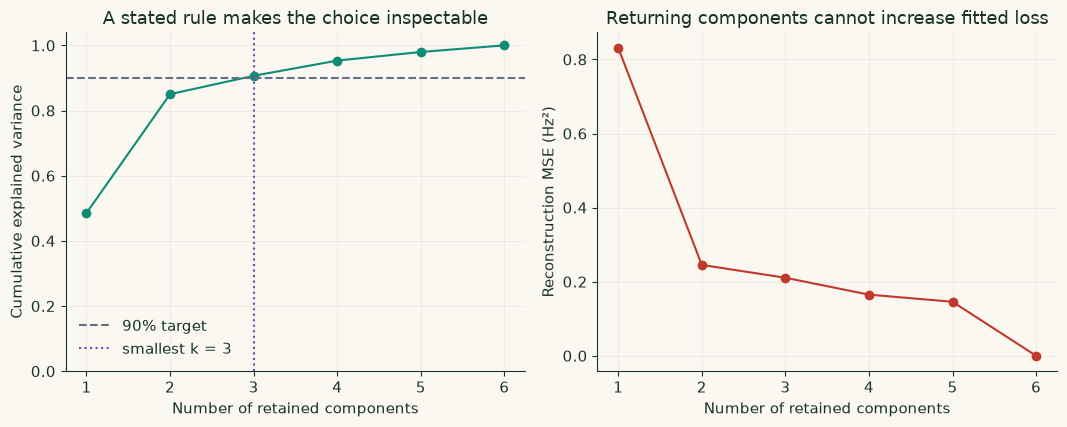

In [16]:
#@title 🔧 Plot and explore retained components and reconstruction
component_counts = np.arange(1, neural_activity_fixed.shape[1] + 1)
reconstruction_mse_by_k = np.array(
    [
        reference_reconstruct_pca(neural_activity_fixed, int(k))[1]
        for k in component_counts
    ]
)

fig, (variance_axis, loss_axis) = plt.subplots(1, 2, figsize=(10.8, 4.4))
variance_axis.plot(
    component_counts,
    neural_cumulative_evr_reference,
    marker="o",
    color=C_NEURO,
)
variance_axis.axhline(0.90, color=C_NEUTRAL, linestyle="--", label="90% target")
variance_axis.axvline(
    neural_k90_reference,
    color=C_SECONDARY,
    linestyle=":",
    label=f"smallest k = {neural_k90_reference}",
)
variance_axis.set(
    xlabel="Number of retained components",
    ylabel="Cumulative explained variance",
    title="A stated rule makes the choice inspectable",
    xticks=component_counts,
    ylim=(0, 1.04),
)
variance_axis.legend(frameon=False)
finish_axes(variance_axis)

loss_axis.plot(
    component_counts,
    reconstruction_mse_by_k,
    marker="o",
    color=C_LOSS,
)
loss_axis.set(
    xlabel="Number of retained components",
    ylabel="Reconstruction MSE (Hz²)",
    title="Returning components cannot increase fitted loss",
    xticks=component_counts,
)
finish_axes(loss_axis)

plt.tight_layout()
plt.show()


reconstruction_explorer_cache = {
    int(k): reference_reconstruct_pca(neural_activity_fixed, int(k))
    for k in component_counts
}
reconstruction_residual_limit = max(
    np.max(np.abs(neural_activity_fixed - result[0]))
    for result in reconstruction_explorer_cache.values()
)
reconstruction_rate_limits = (
    neural_activity_fixed.min(),
    neural_activity_fixed.max(),
)


def explore_neural_reconstruction(component_count=neural_k90_reference):
    """Show the reconstruction and residual as fitted components return."""
    reconstruction, mse, retained_variance = reconstruction_explorer_cache[
        int(component_count)
    ]
    residual = neural_activity_fixed - reconstruction
    rate_minimum, rate_maximum = reconstruction_rate_limits

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12.0, 4.7),
        sharey=True,
        constrained_layout=True,
    )
    original_image = axes[0].imshow(
        neural_activity_fixed,
        aspect="auto",
        cmap="viridis",
        vmin=rate_minimum,
        vmax=rate_maximum,
    )
    axes[1].imshow(
        reconstruction,
        aspect="auto",
        cmap="viridis",
        vmin=rate_minimum,
        vmax=rate_maximum,
    )
    residual_image = axes[2].imshow(
        residual,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-reconstruction_residual_limit,
        vmax=reconstruction_residual_limit,
    )

    reach_centres = np.arange(len(reach_names)) * len(time_values) + 1.5
    for axis, title in zip(
        axes,
        ["Original rates", "Reconstructed rates", "Residual: original − reconstruction"],
    ):
        axis.set(
            xlabel="Neuron",
            xticks=np.arange(len(neuron_names)),
            xticklabels=neuron_names,
            title=title,
        )
        axis.set_yticks(reach_centres)
        axis.set_yticklabels(reach_names, fontsize=8)
    axes[0].set_ylabel("Complete reach (four rows each)")

    rate_colourbar = fig.colorbar(
        original_image,
        ax=axes[:2],
        location="bottom",
        shrink=0.78,
        pad=0.10,
    )
    rate_colourbar.set_label("Simulated firing rate (Hz)")
    residual_colourbar = fig.colorbar(
        residual_image,
        ax=axes[2],
        location="bottom",
        shrink=0.78,
        pad=0.10,
    )
    residual_colourbar.set_label("Residual (Hz)")
    fig.suptitle(
        f"k = {component_count}: retained variance = {retained_variance:.1%}, "
        f"MSE = {mse:.3f} Hz²",
        fontweight="bold",
    )
    plt.show()


if widgets is not None:
    reconstruction_component_control = widgets.IntSlider(
        value=neural_k90_reference,
        min=1,
        max=neural_activity_fixed.shape[1],
        step=1,
        description="components",
        continuous_update=False,
    )
    reconstruction_component_panel = widgets.interactive_output(
        explore_neural_reconstruction,
        {"component_count": reconstruction_component_control},
    )
    display(
        widgets.VBox(
            [
                widgets.HTML(
                    "<b>Explore:</b> return components one at a time. "
                    "The colour scales stay fixed so the residual change is comparable."
                ),
                reconstruction_component_control,
                reconstruction_component_panel,
            ]
        )
    )
else:
    print(
        "Interactive component control unavailable. The stored variance and "
        "loss curves above contain the core result."
    )

## 6. Is the fitted direction stable?

PCA is deterministic for one fixed matrix. A different sample of reaches can produce a different fitted direction. NB-5's bootstrap gives us a way to examine that sensitivity, provided we resample the independent units and refit every data-dependent step.

Here the independent units are complete reaches. Each sampled reach brings all four of its time-bin rows into the bootstrap sample. A reach may appear more than once or not at all. Within every bootstrap sample we refit both the scaler and PCA.

Because signs are arbitrary, we compare a refitted PC1 with the reference PC1 using the absolute dot product. A value near one means that the two fitted axes point along nearly the same line; it is not a confidence level or evidence for a biological mechanism.

### Definitions in plain language

- **Deterministic** means the same PCA implementation fitted to exactly the same matrix gives the same axes, apart from allowed sign conventions and numerical details. It does not mean the axes would be identical in a new sample.
- **Sampling variability** is the change in a result caused by observing a different set of independent units from the same target population.
- A **bootstrap sample** draws units from the observed data with replacement and keeps the resample the same size as the original. Some units repeat and some are absent.
- The **independent unit** is the unit that could reasonably have been sampled independently. Four time bins from one reach are not four independent reaches.
- **Refitting** means relearning every data-dependent quantity in each bootstrap sample. Reusing the original scaler or PCA would hide part of the variation we want to measure.
- For unit-length component vectors, the **dot product** is the cosine of the angle between them. Its absolute value is 1 for the same axis (including a sign flip), about 0 for perpendicular axes, and between these values for partial agreement.

If two consecutive PCs have nearly equal eigenvalues, they may rotate within their shared plane across samples even when the **subspace** is stable. In that case, comparing PC1 with PC1 alone can be misleading; advanced analyses compare the retained subspaces or principal angles. This notebook uses a simpler, well-separated PC1 example first.

**Population-genetics translation:** bootstrapping unrelated participants asks whether the fitted genetic axis is sensitive to which people were sampled. If relatives are present, people within a family are not independent and the family may need to be treated as the unit. In a multi-cohort analysis, resampling whole cohorts or sites asks a different and often more demanding generalisation question. Resampling variants asks about marker-set stability, not participant-sampling stability; because neighbouring SNPs are correlated through LD, a naive one-SNP-at-a-time bootstrap is usually inappropriate, and LD blocks or chromosomes may be more defensible units.

### Try it 6. Can you resample complete reaches and refit PCA?

Produce 1,000 bootstrap refits. Use `np.random.default_rng(606).integers(...)` to make the same reproducible draws as the memo. This gives each 5% tail substantially more than the roughly two refits it would contain if we used only 40 simulations.

1. Draw 12 reach indices with replacement for every refit.
2. For each draw, collect all four rows belonging to every sampled reach. Preserve duplicates when a reach is sampled more than once.
3. Refit `StandardScaler` and a two-component PCA to the bootstrap rows.
4. Store the absolute dot product between the bootstrap PC1 and `reference_pc1`.

Save the integer draws as a `(1000, 12)` array called `student_bootstrap_draws` and the agreements as a length-1,000 array called `student_bootstrap_agreements`.

#### Translate the loop into ordinary language

- `student_bootstrap_draws[b]` is the list of 12 reaches used in bootstrap repetition `b`.
- When a reach number appears twice, copy **all four rows** for that reach twice. Duplicates are a required feature of sampling with replacement.
- Fit a fresh scaler and fresh PCA to those copied rows. This represents repeating the complete analysis on another reach sample.
- Compare the new PC1 weight vector with the reference PC1. `abs(new_pc1 @ reference_pc1)` ignores an arbitrary sign reversal.
- After 1,000 repetitions, percentiles summarise the distribution of agreements. They are not probabilities that PC1 is biologically true.

**Population psychiatric genetics translation:** first state the uncertainty question. *Would the PCs change if different unrelated people were sampled?* Resample people. *Would they change if different families were sampled?* Resample families. *Would the structure generalise across recruitment sites?* A leave-site-out or site-level analysis may be more informative than an individual bootstrap. *Would another approximately independent set of markers give the same axes?* Resample LD-aware blocks or chromosomes. The unit follows the claim; there is no single bootstrap that answers every stability question.

In [17]:
reference_pc1 = neural_scaled_pca_reference.components_[0]
N_BOOTSTRAP_REFITS = 1000

bootstrap_rng = np.random.default_rng(606)
student_bootstrap_draws = bootstrap_rng.integers(
    0,
    len(reach_names),
    size=(N_BOOTSTRAP_REFITS, len(reach_names)),
)
student_bootstrap_agreements = []

for reach_draw in student_bootstrap_draws:
    bootstrap_rows = np.concatenate(
        [
            np.flatnonzero(neural_reach_index == reach_index)
            for reach_index in reach_draw
        ]
    )
    bootstrap_activity = neural_activity[bootstrap_rows]
    bootstrap_scaled = StandardScaler().fit_transform(bootstrap_activity)
    bootstrap_model = PCA(n_components=2).fit(bootstrap_scaled)
    student_bootstrap_agreements.append(
        abs(bootstrap_model.components_[0] @ reference_pc1)
    )

student_bootstrap_agreements = np.asarray(student_bootstrap_agreements)

**Your answer**

The 5th, 50th, and 95th percentiles of the absolute PC1 agreement are approximately **0.957, 0.992, and 0.999**.

These values describe the fitted direction's sensitivity to sampling different complete reaches from this dataset. They do not establish a confidence level, a biological mechanism, or stability in a different population or study design.

In [18]:
#@title 💡 Reference bootstrap and Try it 6 check — open after attempting
bootstrap_rng_reference = np.random.default_rng(606)
bootstrap_draws_reference = bootstrap_rng_reference.integers(
    0,
    len(reach_names),
    size=(N_BOOTSTRAP_REFITS, len(reach_names)),
)
bootstrap_agreements_reference = []

for reach_draw in bootstrap_draws_reference:
    bootstrap_rows = np.concatenate(
        [
            np.flatnonzero(neural_reach_index_fixed == reach_index)
            for reach_index in reach_draw
        ]
    )
    bootstrap_activity = neural_activity_fixed[bootstrap_rows]
    bootstrap_scaled = StandardScaler().fit_transform(bootstrap_activity)
    bootstrap_model = PCA(n_components=2).fit(bootstrap_scaled)
    bootstrap_agreements_reference.append(
        abs(bootstrap_model.components_[0] @ reference_pc1)
    )

bootstrap_agreements_reference = np.asarray(bootstrap_agreements_reference)
bootstrap_agreement_quantiles = np.quantile(
    bootstrap_agreements_reference,
    [0.05, 0.50, 0.95],
)

task6_ready = (
    student_bootstrap_draws is not None
    and student_bootstrap_agreements is not None
)
task6_correct = False
if task6_ready:
    try:
        student_draws_array = np.asarray(student_bootstrap_draws)
        student_agreements_array = np.asarray(student_bootstrap_agreements)
        duplicate_counts = [
            len(np.unique(draw)) < len(draw) for draw in student_draws_array
        ]
        task6_correct = (
            student_draws_array.shape
            == (N_BOOTSTRAP_REFITS, len(reach_names))
            and np.array_equal(student_draws_array, bootstrap_draws_reference)
            and student_agreements_array.shape == (N_BOOTSTRAP_REFITS,)
            and np.all(np.isfinite(student_agreements_array))
            and np.all((0.0 <= student_agreements_array) & (student_agreements_array <= 1.0))
            and any(duplicate_counts)
            and np.allclose(
                student_agreements_array,
                bootstrap_agreements_reference,
                atol=1e-10,
            )
        )
    except (TypeError, ValueError, AttributeError):
        task6_correct = False

soft_check(
    task6_correct,
    "Try it 6 resamples complete reaches and refits the full representation.",
    "check the resampling unit, duplicate reaches, refitting steps, and sign-invariant comparison.",
)

PASS: Try it 6 resamples complete reaches and refits the full representation.


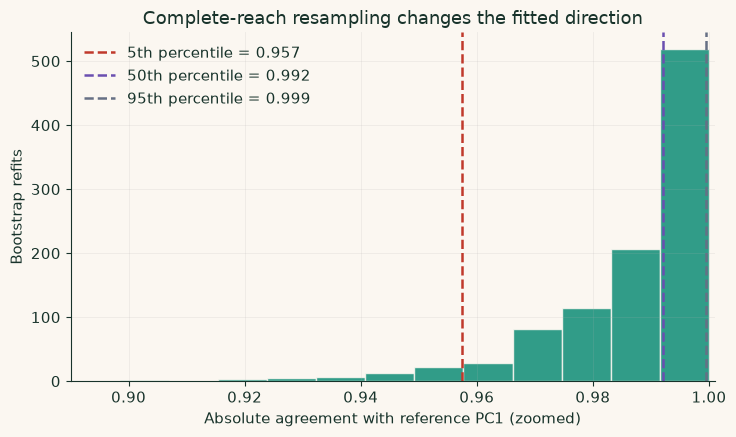

In [19]:
#@title 🔧 Plot the bootstrap direction agreements
agreement_axis_minimum = max(
    0.0,
    np.floor((bootstrap_agreements_reference.min() - 0.005) * 100) / 100,
)
fig, axis = plt.subplots(figsize=(7.5, 4.5))
axis.hist(
    bootstrap_agreements_reference,
    bins=np.linspace(agreement_axis_minimum, 1.0, 14),
    color=C_NEURO,
    alpha=0.85,
    edgecolor=C_PAPER,
)
for probability, value, colour in zip(
    [5, 50, 95],
    bootstrap_agreement_quantiles,
    [C_LOSS, C_SECONDARY, C_NEUTRAL],
):
    axis.axvline(
        value,
        color=colour,
        linewidth=1.8,
        linestyle="--",
        label=f"{probability}th percentile = {value:.3f}",
    )
axis.set(
    xlabel="Absolute agreement with reference PC1 (zoomed)",
    ylabel="Bootstrap refits",
    title="Complete-reach resampling changes the fitted direction",
    xlim=(agreement_axis_minimum, 1.001),
)
axis.legend(frameon=False, loc="upper left")
finish_axes(axis)
plt.tight_layout()
plt.show()

This compact bootstrap deliberately stops at one component-direction summary. The Lecture 6 asset-generation master also compared larger real EEG analyses, repeated reaches, near-tied axes, and retained subspaces. Those are useful advanced investigations, but they are not required to learn the core resample-refit-interpret workflow in this weekly notebook.

## 7. When should we use another method?

PCA uses global linear directions. A curved dataset can have a simple low-dimensional structure that no flat PCA plane can unfold faithfully. t-SNE asks a different question: it constructs a two-dimensional display that tries to keep nearby observations near one another. Its axes, global gaps, cluster sizes, and arrangement are not literal measurements in the original feature space.

The supplied example uses one small Swiss roll. Colour marks position along the roll so that we can see which neighbours should remain nearby. Two t-SNE settings use the same observations but produce different global arrangements.

### Definitions in plain language

- **Linear** means each component score is a weighted sum of the original features. A PCA component is one straight axis through the full cloud.
- **Nonlinear structure** can bend or curve. A flat plane may overlap parts of a curved surface that were separate before projection.
- **Local neighbours** are observations close to one another.
- **Global geometry** is the overall arrangement: distances between far-away groups, group sizes, angles, and the placement of one cluster relative to another.
- **Out-of-sample transformation** means a fitted method can place a new observation into the same existing coordinate system. Standard PCA supports this directly through `transform`. Standard scikit-learn t-SNE is primarily a fitted display and does not provide the same simple, stable `transform` operation.

PCA and t-SNE therefore answer different questions. PCA gives a global linear coordinate system with explicit feature weights and reproducible projection rules. t-SNE can reveal possible local neighbourhood patterns in a display, but its axes have no original-unit meaning and its global gaps can change with settings.

**Population-genetics translation:** PCA remains a common first choice for genetic structure because participant scores can be used as covariates and reference weights can project future samples. t-SNE or UMAP can be useful secondary exploratory displays, especially for complicated local patterns, but a striking cluster map is not automatically a population definition and should not replace a validated stratification-control strategy. Colour the display by reference ancestry, study, site, platform, batch, missingness, kinship, and phenotype separately before interpreting it.

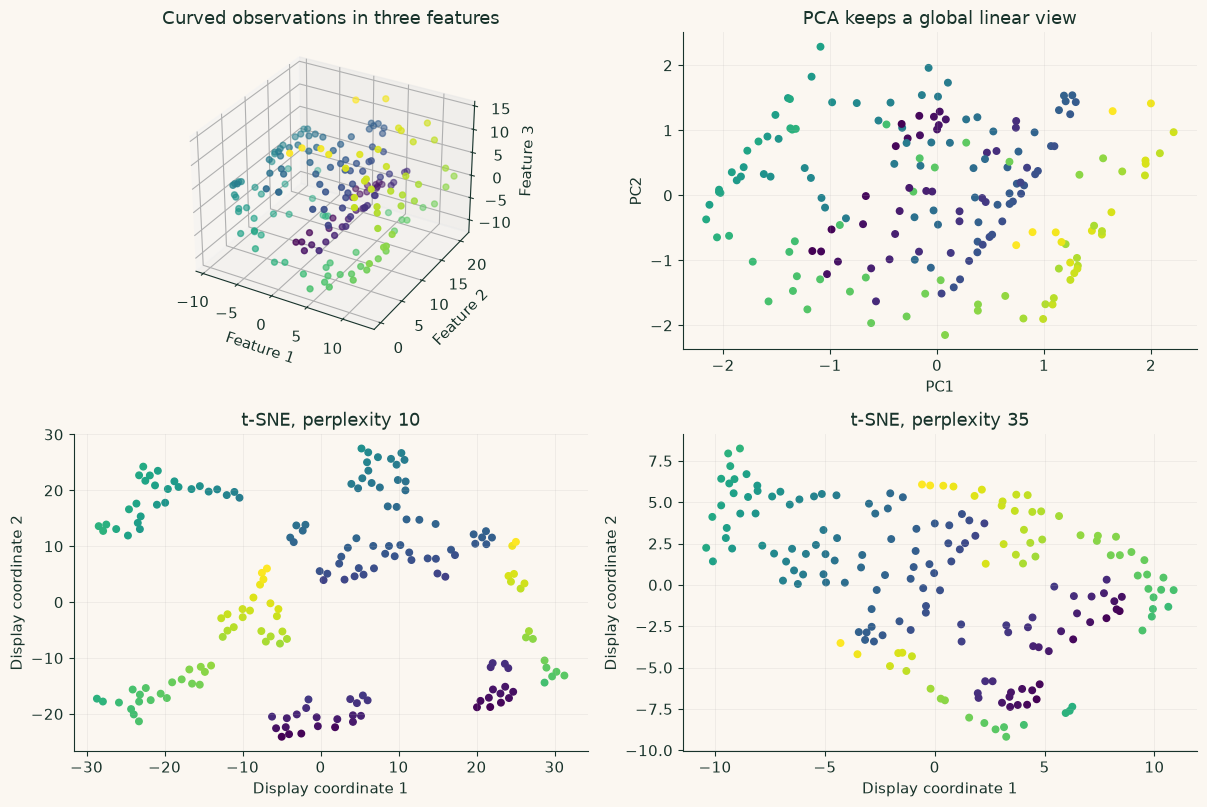

In [19]:
#@title 🔧 Build and plot the nonlinear comparison
swiss_points, swiss_position = make_swiss_roll(
    n_samples=180,
    noise=0.03,
    random_state=77,
)
swiss_scaled = StandardScaler().fit_transform(swiss_points)
swiss_pca_scores = PCA(n_components=2).fit_transform(swiss_scaled)

tsne_low = TSNE(
    n_components=2,
    perplexity=10,
    init="pca",
    learning_rate="auto",
    max_iter=750,
    random_state=77,
).fit_transform(swiss_scaled)
tsne_high = TSNE(
    n_components=2,
    perplexity=35,
    init="pca",
    learning_rate="auto",
    max_iter=750,
    random_state=77,
).fit_transform(swiss_scaled)

fig = plt.figure(figsize=(12.2, 8.2))
raw_axis = fig.add_subplot(2, 2, 1, projection="3d")
pca_axis = fig.add_subplot(2, 2, 2)
low_axis = fig.add_subplot(2, 2, 3)
high_axis = fig.add_subplot(2, 2, 4)

raw_axis.scatter(
    swiss_points[:, 0],
    swiss_points[:, 1],
    swiss_points[:, 2],
    c=swiss_position,
    cmap="viridis",
    s=18,
)
raw_axis.set_title("Curved observations in three features")
raw_axis.set_xlabel("Feature 1")
raw_axis.set_ylabel("Feature 2")
raw_axis.set_zlabel("Feature 3")

pca_axis.scatter(
    swiss_pca_scores[:, 0],
    swiss_pca_scores[:, 1],
    c=swiss_position,
    cmap="viridis",
    s=22,
)
pca_axis.set(
    xlabel="PC1",
    ylabel="PC2",
    title="PCA keeps a global linear view",
)
finish_axes(pca_axis)

low_axis.scatter(tsne_low[:, 0], tsne_low[:, 1], c=swiss_position, cmap="viridis", s=22)
low_axis.set(
    xlabel="Display coordinate 1",
    ylabel="Display coordinate 2",
    title="t-SNE, perplexity 10",
)
finish_axes(low_axis)

high_axis.scatter(tsne_high[:, 0], tsne_high[:, 1], c=swiss_position, cmap="viridis", s=22)
high_axis.set(
    xlabel="Display coordinate 1",
    ylabel="Display coordinate 2",
    title="t-SNE, perplexity 35",
)
finish_axes(high_axis)

plt.tight_layout()
plt.show()

### Try it 7. Which method answers which scientific question?

Answer each scenario with **PCA**, **t-SNE**, **both in sequence**, **a grouped predictive model**, **a whole-unit bootstrap**, or **neither**. Give one reason and one limitation for every choice.

1. You need reproducible coordinates that can transform future observations and approximately reconstruct the original six neural features.
2. You want an exploratory display of possible local neighbours in a curved dataset and will repeat the display across settings.
3. You want to estimate whether a label can be predicted for entirely held-out participants.
4. You want to know how much a fitted PCA direction changes when different complete reaches are sampled.
5. A t-SNE map shows two widely separated groups. What conclusion about the distance between those groups is not justified by the map alone?

#### A decision recipe

Ask four questions before naming a method:

1. Is the aim **description/compression**, **visual exploration**, **prediction**, or **uncertainty**?
2. Must future observations enter the same coordinate system?
3. Is local neighbourhood structure enough, or must global distances be interpretable?
4. What is the independent unit: row, person, family, cohort, site, or genomic block?

Then match aim to tool:

- Use **PCA** for an explicit linear coordinate system, feature weights, future projection, and approximate reconstruction.
- Use **t-SNE** for cautious exploration of possible local neighbourhoods, repeated across settings.
- Use a **grouped predictive model** when the claim concerns performance on wholly new participants, families, or sites. PCA may be one training-only step inside that model, but PCA alone does not predict a diagnosis.
- Use a **whole-unit bootstrap** when the question is how a statistic or fitted representation changes across resampled independent units.
- Choose **neither** when the proposed claim is causal but the design and method are only descriptive.

**Population psychiatric genetics translation:** a genetic PC can help describe population structure or enter a GWAS as a covariate. A phenotype classifier requires a supervised model and evaluation on genuinely held-out people or cohorts. A bootstrap can assess stability but does not remove population stratification. A t-SNE gap does not prove two ancestral populations, two diagnostic subtypes, or a biologically meaningful distance. These tools can be used in sequence, but each retains its own interpretation limits.

**Your answer**

1. **Method: PCA.** It supplies reproducible coordinates for transforming future observations and supports approximate inverse reconstruction from retained components. Its limitation is that it captures global linear variance, so a low-dimensional reconstruction can miss nonlinear structure and information in discarded components.
2. **Method: t-SNE.** It is appropriate for an exploratory display of possible local neighbours in curved data, and repeating settings checks how dependent the display is on the configuration. Its limitation is that its axes, global gaps, cluster sizes, and layout are not directly interpretable measurements and can change with settings or random initialisation.
3. **Method: a grouped predictive model.** Grouping by participant tests whether labels can be predicted for entirely held-out people while all preprocessing is fitted within the training folds. Its limitation is that performance generalises only to populations resembling the sampled participants, and prediction does not establish mechanism or causation.
4. **Method: a whole-unit bootstrap.** Resampling complete reaches and refitting the scaler and PCA estimates how the fitted direction changes across reach-level resamples. Its limitation is that it depends on the observed reaches being representative and does not test stability under a different population or data-generating process.
5. The unsupported conclusion is that the large gap proves the two groups are equally far apart in the original feature space, or are objectively distinct clusters. t-SNE aims mainly to preserve local neighbourhoods, not global distances, so separation in the display alone cannot support that claim.

## What can this notebook support?

You can now carry out a complete small PCA workflow: identify the matrix objects, centre and project observations, fit PCA, read scores and weights, choose a scaling convention, reconstruct in original units, and examine one form of sampling sensitivity. You can also state why explained variance is not task relevance and why a striking t-SNE display needs cautious interpretation.

The next lecture asks how a neural network can learn nonlinear features for a prediction task. Unlike PCA, those features are shaped by a training objective. The same discipline still applies: define the observations, fit every data-dependent step honestly, and limit the claim to what the design supports.

## A practical population psychiatric genetics workflow

The following is a conceptual checklist, not a substitute for a consortium's analysis plan or genotype-QC protocol.

1. **State the aim.** Are you visualising structure, constructing GWAS covariates, projecting a new cohort, checking sample identity, or building a psychiatric prediction model? These aims require different validation.
2. **Define the matrix.** Usually rows are participants and columns are allele dosages at selected variants. Record genome build, allele convention, imputation source, and missing-data handling.
3. **Perform sample and variant QC.** Investigate call rate, genotype quality, heterozygosity, sex checks where appropriate, duplicates, kinship, allele-frequency anomalies, and batch/site effects using a pre-specified protocol.
4. **Construct an ancestry-PCA marker set.** A common choice is high-quality, reasonably common autosomal variants after LD pruning and handling long-range-LD regions. The exact filters are study-dependent and should be reported, not copied blindly.
5. **Choose the fitting set.** Close relatives and extreme outliers can strongly shape axes. A common strategy is to fit in a relatively unrelated reference subset and project other participants. If external reference populations are merged, harmonisation and batch checks are essential.
6. **Fit with genetics-aware software.** For very large data, use tools designed for genotype storage and approximate PCA rather than converting the entire dataset into a dense pandas or NumPy table.
7. **Interrogate every leading PC.** Plot PC pairs and compare scores with recruitment geography, reference ancestry, family structure, study, site, array, sequencing centre, processing batch, missingness, and case/control status. Look at variant weights when a local genomic region may dominate.
8. **Choose downstream adjustment deliberately.** In a GWAS, selected PC scores can enter each association model as covariates, often alongside relevant technical and design variables. Mixed-model approaches may also model relatedness and structure. There is no automatic universal number of PCs.
9. **Protect prediction evaluation.** If the aim is psychiatric-status or outcome prediction in new people, fit PCA and all other data-dependent preprocessing inside the appropriate participant-, family-, cohort-, or site-level training split, unless a fixed external reference is used.
10. **Project consistently.** To place a new cohort into an existing PC space, use harmonised variants, the reference allele frequencies, and the saved reference weights. Do not refit and assume that components with the same number are the same axes.
11. **Run sensitivity analyses.** Check alternative QC thresholds, fitting subsets, PC counts, batch covariates, ancestry groupings or continuous models, and—where appropriate—leave-cohort-out analyses.
12. **Limit the claim.** PCs can help control measured genome-wide structure. They do not prove causal ancestry effects, turn socially defined race into a genetic variable, guarantee removal of all confounding, or make a polygenic score equally transferable across populations.

### Why population structure can confound psychiatric GWAS

Imagine that cases were recruited mainly from region A and controls mainly from region B. If allele frequencies differ between those regions for historical demographic reasons, many variants can appear associated with diagnosis even when they have no causal effect on the disorder. PCA can summarise some of the genome-wide region-related differences, and including suitable scores as covariates can reduce this confounding. The stronger remedy is still good sampling and harmonisation: if site, platform, ancestry, and diagnosis are almost perfectly aligned, a few covariates may not identify which source caused the difference.

### Primary resources for the genetics transition

- [Price et al. (2006), *Principal components analysis corrects for stratification in genome-wide association studies*](https://www.nature.com/articles/ng1847) introduces the use of genome-wide PCA axes to model ancestry-related stratification in association studies.
- [PLINK 2.0 population-stratification and PCA documentation](https://www.cog-genomics.org/plink/2.0/strat) describes variance-standardised relationship-matrix PCA, sample scores, allele weights, approximate PCA, kinship concerns, and diagnostic checks for batch effects and outliers.
- [PLINK 2.0 PCA projection documentation](https://www.cog-genomics.org/plink/2.0/score#pca_projection) shows why reference allele frequencies and saved allele weights are required to project new samples into an existing space.
- [PLINK 2.0 relationship-matrix documentation](https://www.cog-genomics.org/plink/2.0/distance) explains genotype variance standardisation and why very-low-frequency variants require care.

> A good learning progression is: understand every number in the four-observation example; explain scores versus weights without code; reproduce PCA on a small QC'd genotype subset; and only then move to PLINK or another genotype-aware tool for cohort-scale analysis.

## Automated reference checks

The five task-specific `PASS` or `TO DO` messages assess the student-written coding tasks. The assertions below protect the supplied datasets, reference calculations, and displayed examples. Passing them does not grade the written responses in Try it 1 or Try it 7.

In [20]:
#@title 🔧 Notebook-integrity checks
assert np.array_equal(small_cloud, small_cloud_fixed), "The supplied small cloud changed unexpectedly."
assert small_cloud_fixed.shape == (4, 2), "The opening cloud must contain four observations and two features."
assert np.allclose(small_mean_reference, [2.5, 2.0]), "The small-cloud means changed unexpectedly."
assert np.allclose(
    small_covariance_reference,
    [[5 / 3, 1.0], [1.0, 2 / 3]],
), "The small-cloud covariance changed unexpectedly."
assert candidate_variances_reference[1] > candidate_variances_reference[0], (
    "The diagonal candidate should retain more score variance than the horizontal candidate."
)
assert np.isclose(total_centred_ss_reference, 7.0), (
    "The four centred observations must contain seven squared units in total."
)
assert np.allclose(candidate_captured_ss_reference, [5.0, 6.5]), (
    "The horizontal and diagonal candidates must capture 5.0 and 6.5 squared units."
)
assert np.allclose(candidate_lost_ss_reference, [2.0, 0.5]), (
    "The horizontal and diagonal candidates must lose 2.0 and 0.5 squared units."
)
assert np.allclose(
    candidate_captured_ss_reference + candidate_lost_ss_reference,
    total_centred_ss_reference,
), "Captured and orthogonal sums of squares must partition the same total."
assert np.isclose(small_evr_reference.sum(), 1.0), "The two-component PCA must retain all small-cloud variance."
assert np.allclose(
    small_pca_reference.inverse_transform(small_scores_reference),
    small_cloud_fixed,
), "Keeping both small-cloud components must reconstruct the observations."

assert np.array_equal(neural_activity, neural_activity_fixed), "The supplied neural matrix changed unexpectedly."
assert neural_activity_fixed.shape == (48, 6), "The neural matrix must contain 48 observations and six features."
assert np.all(np.isfinite(neural_activity_fixed)), "The simulated neural rates must be finite."
assert neural_activity_fixed.min() > 0.0, "The simulated neural rates must remain positive."
assert np.array_equal(
    np.bincount(neural_reach_index_fixed),
    np.repeat(4, len(reach_names)),
), "Every reach must contribute four complete time-bin rows."
assert np.allclose(neural_scaled_reference.mean(axis=0), 0.0, atol=1e-12), (
    "Standardisation must centre all six neural features."
)
assert 1 <= neural_k90_reference <= neural_activity_fixed.shape[1], (
    "The retained dimension must be valid for the six-feature matrix."
)
assert np.all(np.diff(reconstruction_mse_by_k) <= 1e-12), (
    "Reconstruction loss must not increase as fitted components return."
)
assert reconstruction_mse_by_k[-1] < 1e-20, (
    "Keeping all six fitted components must reconstruct apart from rounding."
)

assert bootstrap_draws_reference.shape == (N_BOOTSTRAP_REFITS, 12), (
    "The stability example must draw 12 complete reaches on every refit."
)
assert bootstrap_agreements_reference.shape == (N_BOOTSTRAP_REFITS,), (
    "The stability example must return one PC1 agreement per refit."
)
assert np.all(
    (0.0 <= bootstrap_agreements_reference)
    & (bootstrap_agreements_reference <= 1.0)
), "Sign-invariant direction agreements must lie from zero to one."

assert swiss_points.shape == (180, 3), "The nonlinear example must contain 180 three-feature observations."
assert swiss_pca_scores.shape == (180, 2), "PCA must return two scores per nonlinear observation."
assert tsne_low.shape == (180, 2) and tsne_high.shape == (180, 2), (
    "Each t-SNE display must contain two coordinates per observation."
)
assert np.all(np.isfinite(tsne_low)) and np.all(np.isfinite(tsne_high)), (
    "The t-SNE display coordinates must be finite."
)
assert not np.allclose(tsne_low, tsne_high), (
    "Changing perplexity should produce a distinct setting-dependent layout."
)

print("Supplied data and reference calculations passed.")

Supplied data and reference calculations passed.


In [21]:
print(
    "Review all seven Try it tasks and the five coding-task PASS or TO DO "
    "messages before submitting."
)

Review all seven Try it tasks and the five coding-task PASS or TO DO messages before submitting.


## What should you submit?

Before saving your copy, check that you have done the following.

- Answered the prediction and feature-deletion questions in Try it 1.
- Centred the cloud, calculated covariance, and compared projected variance in Try it 2.
- Fitted PCA independently and identified scores, weights, and explained variance in Try it 3.
- Compared raw and standardised PCA and stated the training-only fitting rule in Try it 4.
- Completed the reusable reconstruction function, selected `k`, and reported original-unit loss in Try it 5.
- Resampled complete reaches, refitted the scaler and PCA, and interpreted stability in Try it 6.
- Chosen methods from all five scientific scenarios in Try it 7.
- Run the notebook from top to bottom and checked that the five coding-task messages report `PASS`.

**Optional feedback for the lecturer**

- Which task most clearly connected the geometry with the software output?
- Which task required the most independent coding?
- If you used an AI assistant, what did it help with, and how did you check its answer?